In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated, Optional
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI

d:\Lang_Graph_Concepts\langgraphvenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
None of PyTorch, TensorFlow >= 2.0, or Flax have been found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [2]:
load_dotenv()

True

In [5]:
class SubState(TypedDict):
    input_txt : str
    translated_txt : str

In [6]:
parent_llm = ChatOpenAI(model='gpt-4o-mini')
child_llm = ChatOpenAI(model='gpt-4o')

In [7]:
def translate_text(state:SubState):
    prompt = f"""translate the following text to hindi. keep it simple and clean do not add extra content.
    
    Text: {state['input_txt']}""".strip()

    translated_text = child_llm.invoke(prompt).content

    return {'translated_txt': translate_text}

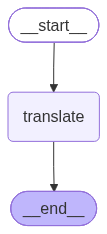

In [8]:
subgraph_builder = StateGraph(SubState)

subgraph_builder.add_node('translate',translate_text)

subgraph_builder.add_edge(START,'translate')
subgraph_builder.add_edge('translate',END)

subgraph = subgraph_builder.compile()

subgraph

In [3]:
class ParentState(TypedDict):
    question : str
    answer_en : str
    answer_hin : str

In [12]:
def generate_eng(state:ParentState):
    eng_res = parent_llm.invoke(f"You are helpfull assistant answer clearly. \n\n Question:{state['question']}.").content

    return {'answer_en':eng_res}

In [10]:
def translate_eng(state:ParentState):
    res = subgraph.invoke({'input_txt':state['answer_en']}) #type:ignore

    return {'answer_hin':res['translated_txt']}

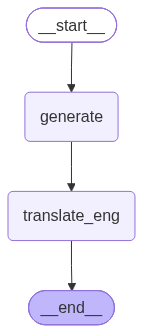

In [15]:
graph_builder = StateGraph(ParentState)

graph_builder.add_node('generate',generate_eng)
graph_builder.add_node('translate_eng',translate_eng)

graph_builder.add_edge(START,'generate')
graph_builder.add_edge('generate','translate_eng')
graph_builder.add_edge('translate_eng',END)

graph = graph_builder.compile()

graph

In [16]:
graph.invoke({'question':'what is quantum physics'})#type:ignore

{'question': 'what is quantum physics',
 'answer_en': 'Quantum physics, also known as quantum mechanics, is a fundamental branch of physics that deals with the behavior of matter and energy at very small scales, typically at the level of atoms and subatomic particles. Unlike classical physics, which describes the macroscopic world, quantum physics introduces concepts that describe how particles behave in ways that can be counterintuitive.\n\nKey principles of quantum physics include:\n\n1. **Wave-Particle Duality**: Particles, such as electrons and photons, exhibit both particle-like and wave-like properties. This means they can behave like discrete particles in some experiments and like waves in others.\n\n2. **Quantum Superposition**: Particles can exist in multiple states simultaneously until they are measured or observed. For example, a particle can be in several locations at once, and it only "chooses" a specific location when observed.\n\n3. **Quantum Entanglement**: Particles ca